# Modular enhancer-hijacking pipeline

Run the full TSS-centred analysis + distance sweep with **AlphaGenome, Borzoi, or Enformer** — swap one object.

**How to use**
1. `pip install -r tools/requirements.txt` (install what your model needs).
2. AlphaGenome → put `ALPHA_GENOME_API_KEY=...` in a `.env` at the repo root. Borzoi / Enformer → need a CUDA GPU.
3. Use the **`.venv` kernel** (top-right). In the last cell set `MODELS`, then **Run All**.

All code lives in `tools/`. To add a model, add one `Predictor` subclass in `tools/seqtools.py`.

In [1]:
import os, sys
# Repo root = the folder containing `fusionseq` (walk up; cwd-independent, safe to re-run).
root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(root, 'fusionseq')) and os.path.dirname(root) != root:
    root = os.path.dirname(root)
assert os.path.isdir(os.path.join(root, 'fusionseq')), 'run this from inside the repo'
TOOLS = os.path.join(root, 'v2', 'modular', 'tools')
sys.path.insert(0, TOOLS)                 # the library
os.chdir(root)                            # AlphaGenome/Borzoi use relative paths (.env, raw/)

# Drop any stale cached copies so a long-running kernel picks up the current tools/ code.
for _m in ('seqtools', 'enformer', 'candidates'):
    sys.modules.pop(_m, None)

import seqtools as st
from candidates import CANDIDATES

cand = CANDIDATES['GATA2-MECOM']          # <- swap candidate
cand['exons'] = st.fetch_exons(cand['tx'])
print('candidate:', cand['gene'], '| models:', list(st.MODELS))

candidate: EVI1 (MECOM) | models: ['AlphaGenome', 'Borzoi', 'Enformer']


/home/codingnewt/MLCB/Borzoi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/codingnewt/MLCB/Borzoi/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:553: UserWarning: torch.utils.checkpoint.checkpoint_sequential: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/codingnewt/MLCB/Borzoi/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/home/codingnewt/MLCB/Borzoi/v2/mod

Enformer: skipped [100] kb (beyond the 196 kb window)


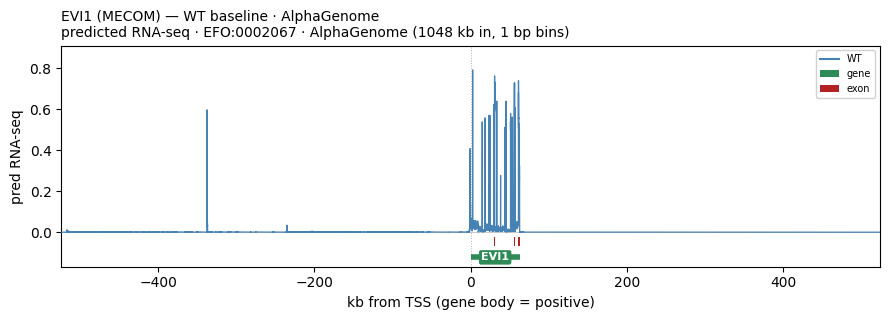

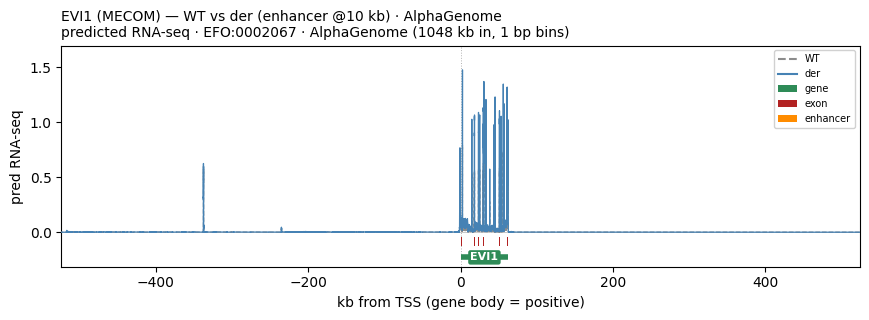

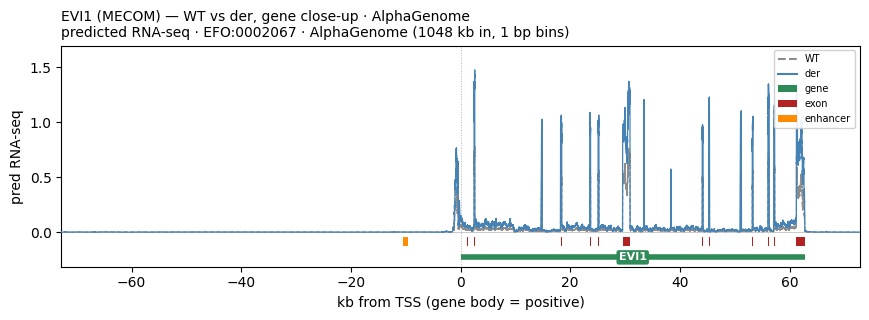

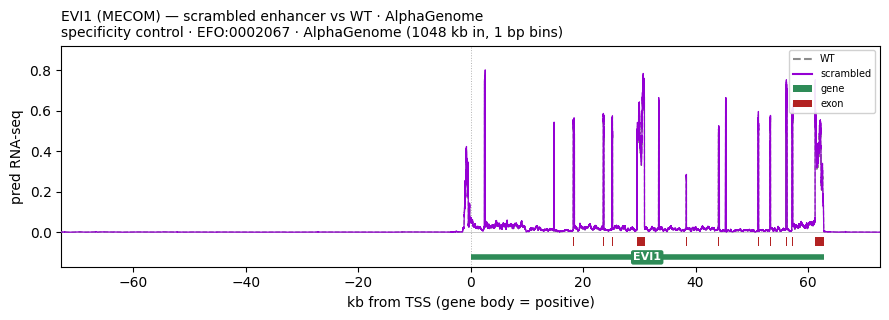

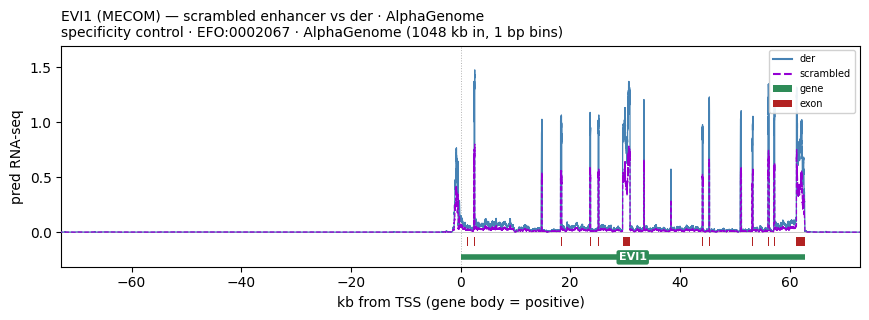

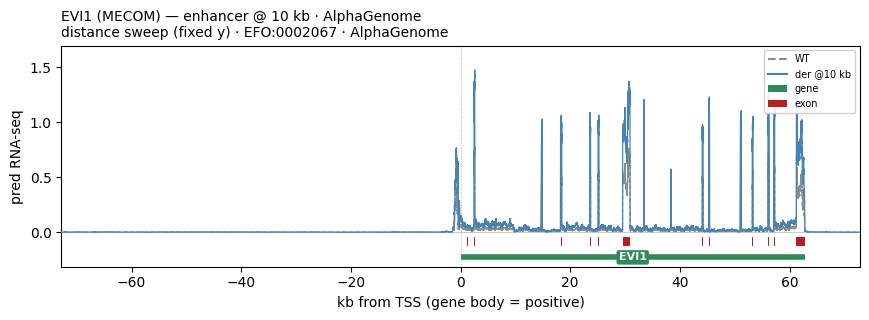

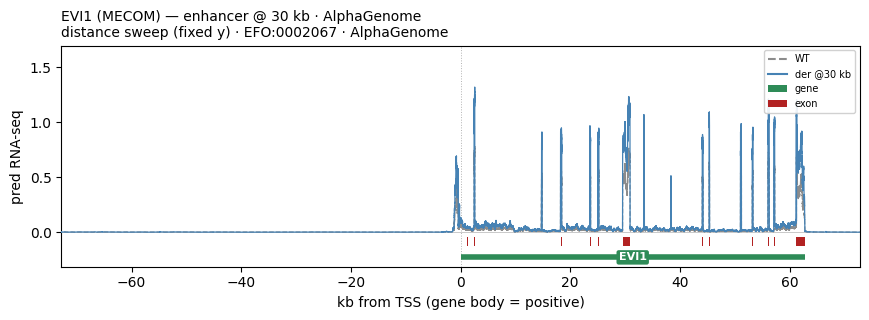

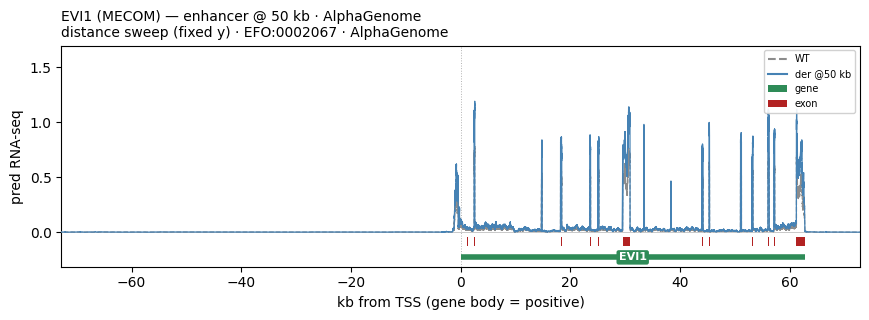

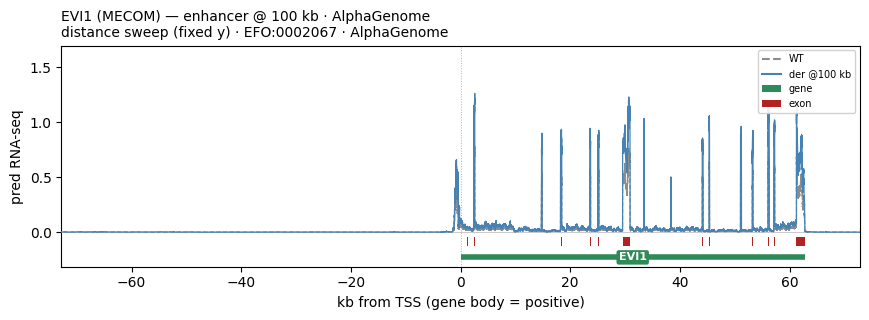

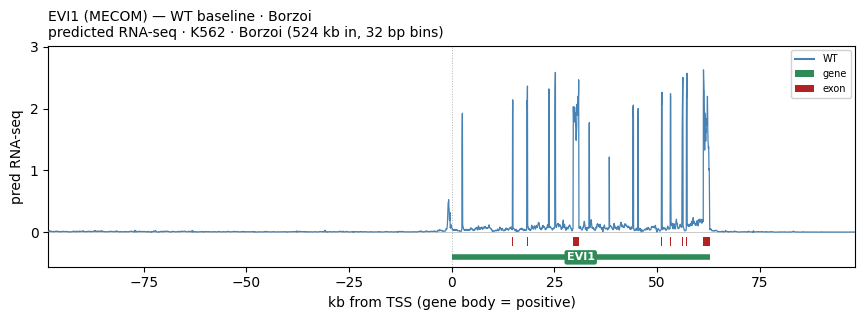

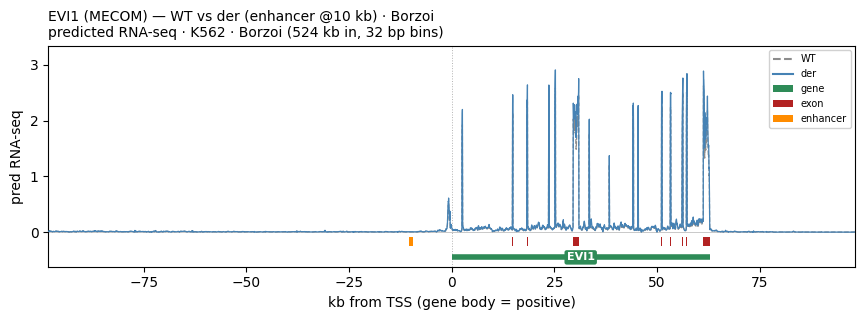

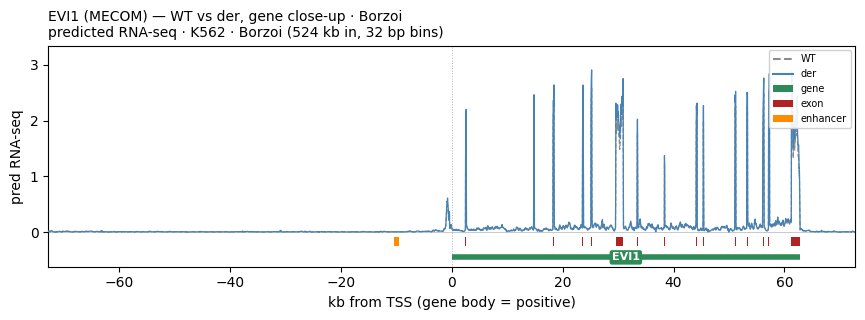

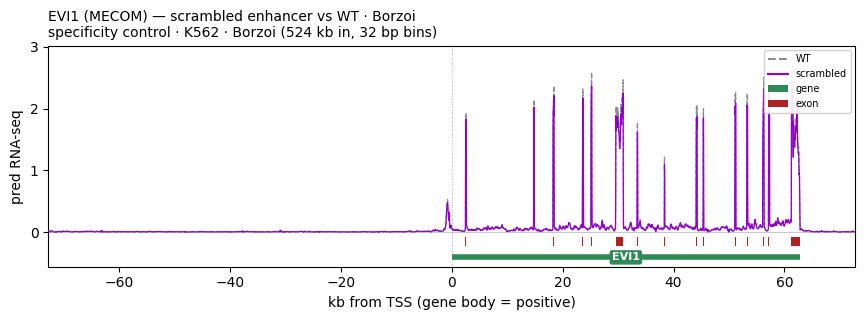

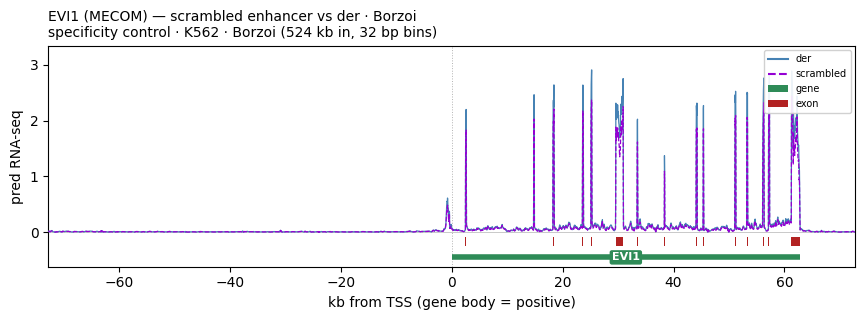

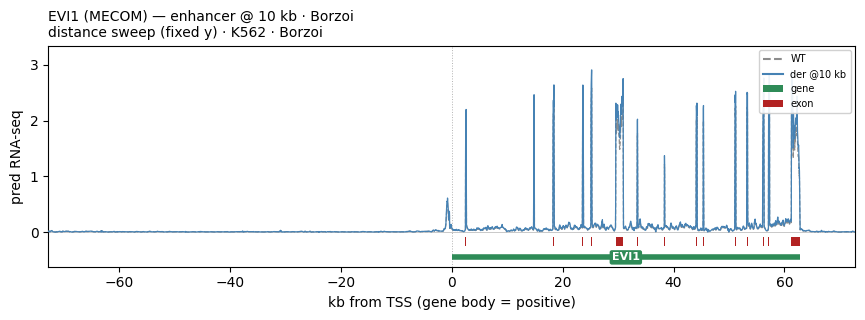

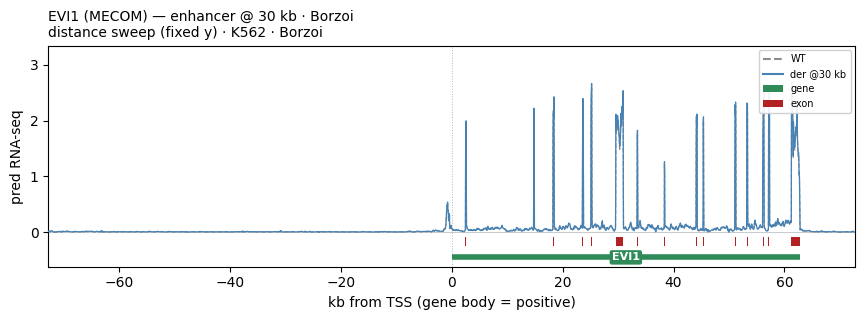

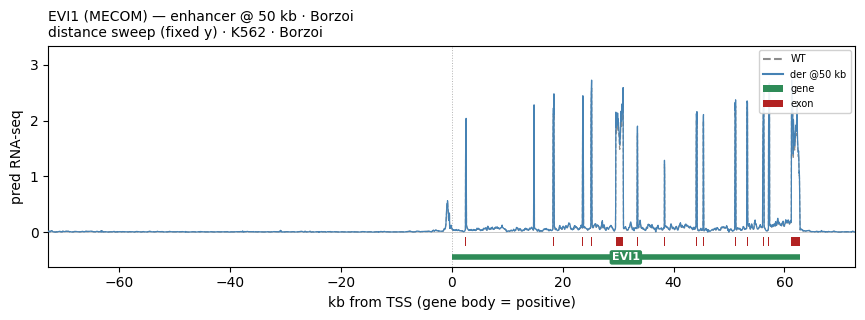

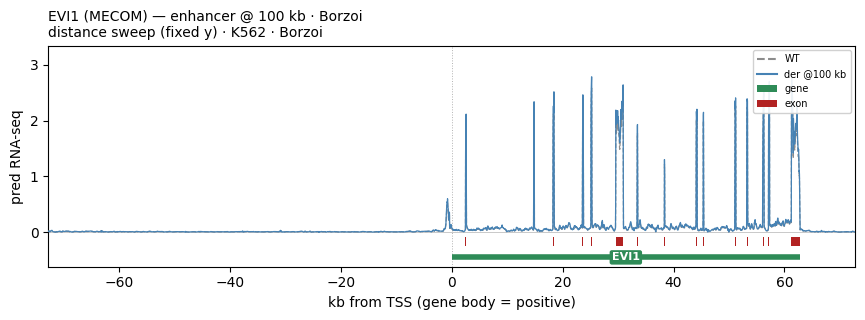

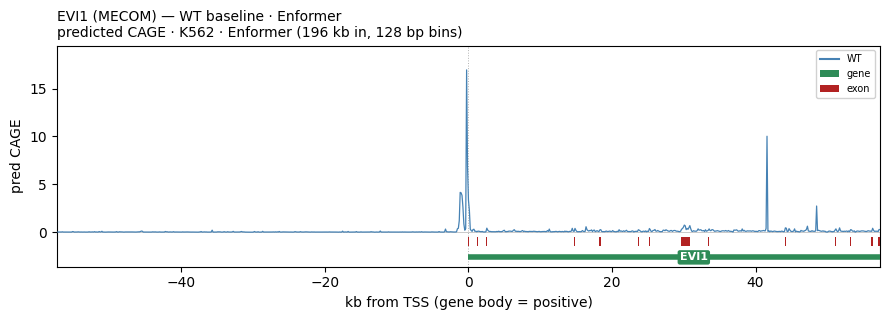

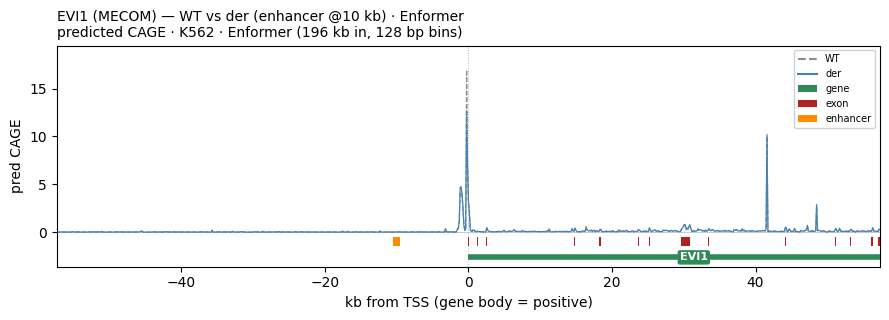

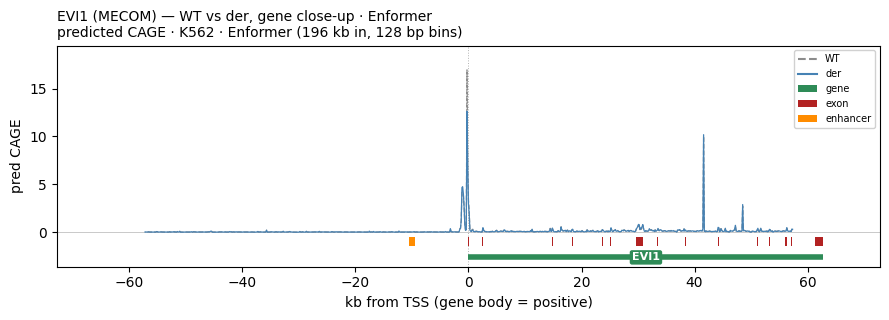

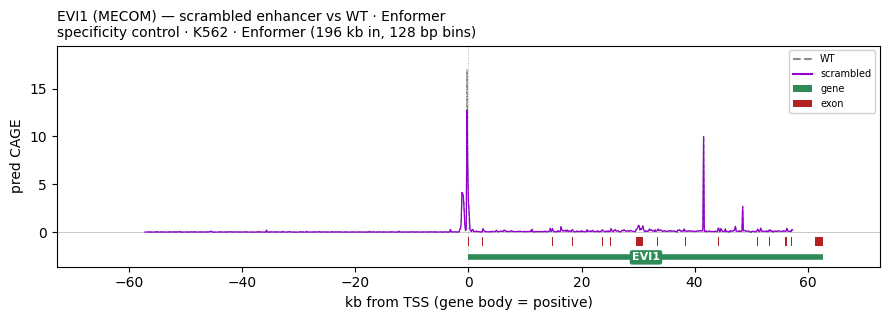

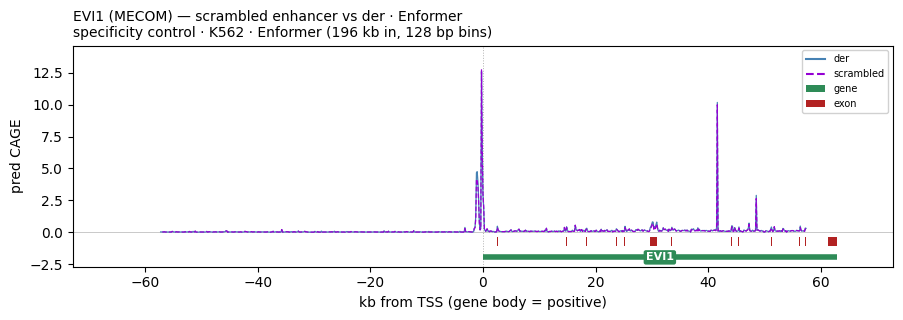

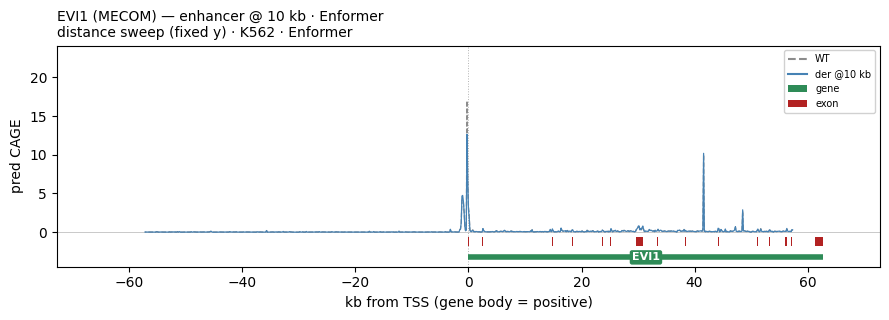

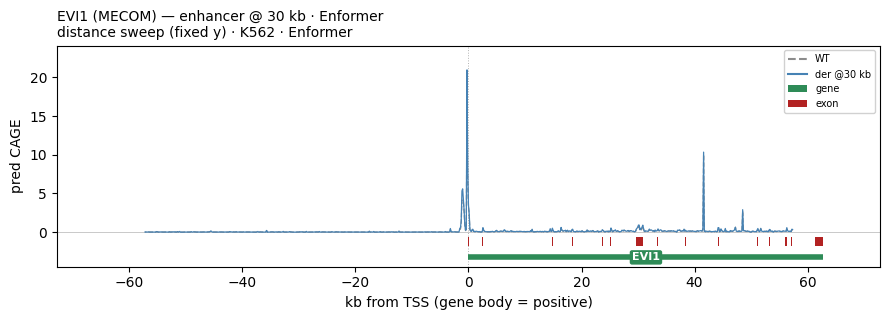

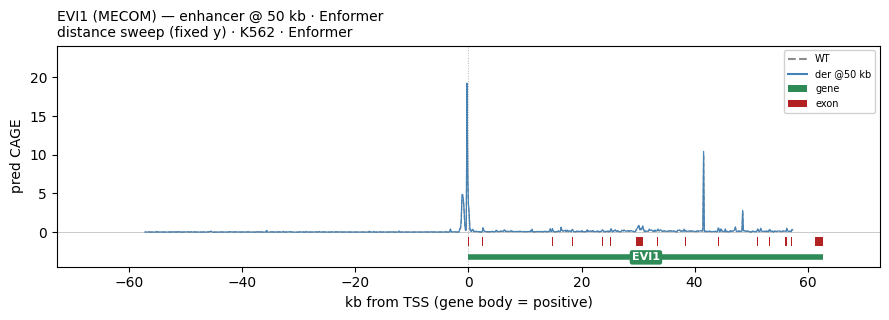

In [2]:
MODELS = [st.AlphaGenome, st.Borzoi, st.Enformer]      # <- pick any subset

for Model in MODELS:
    pred = Model()
    st.analyze(pred, cand)            # WT baseline · WT vs der · gene close-up · scramble controls
    st.distance_sweep(pred, cand)     # der vs WT at 10/30/50/100 kb (auto-capped to the window)